<a href="https://colab.research.google.com/github/gayathrivadthya3-pixel/CODTECH_TASK3/blob/main/image_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# STEP 1: LOAD CIFAR-10 DATASET


(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Class labels
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


In [3]:
# =========================================================
# STEP 2: DATA PREPROCESSING
# =========================================================

# Normalize pixel values (0 to 255 → 0 to 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Display dataset shapes
print("Training Images Shape:", X_train.shape)
print("Testing Images Shape:", X_test.shape)


Training Images Shape: (50000, 32, 32, 3)
Testing Images Shape: (10000, 32, 32, 3)


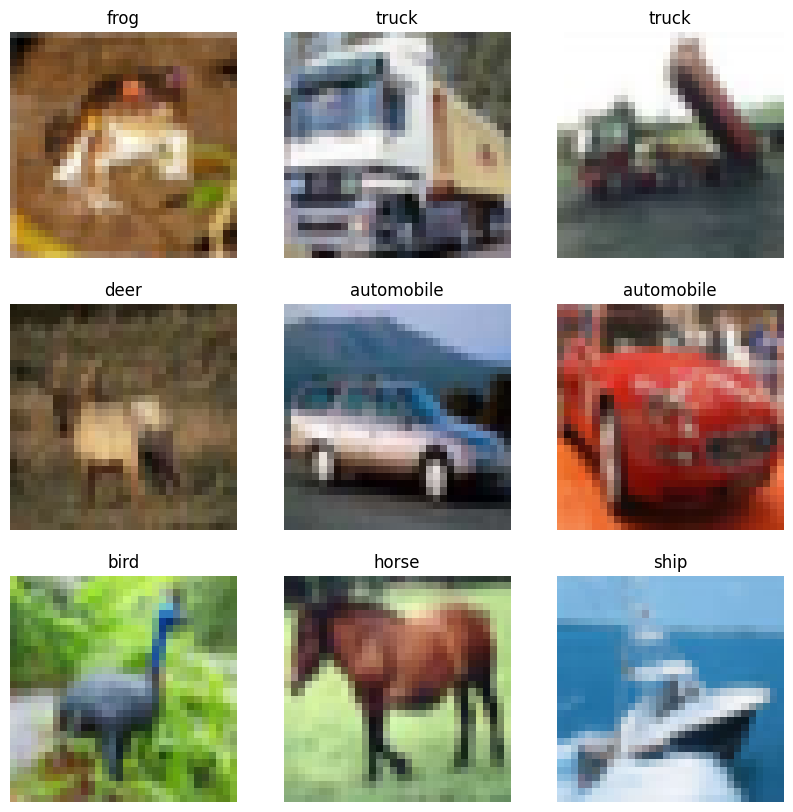

In [4]:
# =========================================================
# STEP 3: VISUALIZE SAMPLE IMAGES
# =========================================================

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis('off')

plt.show()

In [5]:

# =========================================================
# STEP 4: BUILD CNN MODEL
# =========================================================

model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))

# Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

# Third Convolution Layer
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(
    64,
    activation='relu'
))

# Output Layer
model.add(layers.Dense(
    10,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# =========================================================
# STEP 5: MODEL SUMMARY
# =========================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# =========================================================
# STEP 6: COMPILE MODEL
# =========================================================

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [8]:
# =========================================================
# STEP 7: TRAIN MODEL
# =========================================================

history = model.fit(

    X_train,

    y_train,

    epochs=10,

    validation_data=(X_test, y_test)
)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.4585 - loss: 1.4957 - val_accuracy: 0.5507 - val_loss: 1.2572
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.6017 - loss: 1.1289 - val_accuracy: 0.6180 - val_loss: 1.0737
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6624 - loss: 0.9643 - val_accuracy: 0.6731 - val_loss: 0.9254
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.6962 - loss: 0.8677 - val_accuracy: 0.6713 - val_loss: 0.9377
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.7249 - loss: 0.7952 - val_accuracy: 0.6834 - val_loss: 0.9145
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7428 - loss: 0.7381 - val_accuracy: 0.7098 - val_loss: 0.8386
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.7569 - loss: 0.6927 - val_accuracy: 0.7111 - val_loss: 0.8439
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7735 -

In [9]:
# =========================================================
# STEP 8: EVALUATE MODEL
# =========================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)

print("\nTest Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7202 - loss: 0.8656

Test Accuracy: 0.7202000021934509

Test Loss: 0.865594744682312


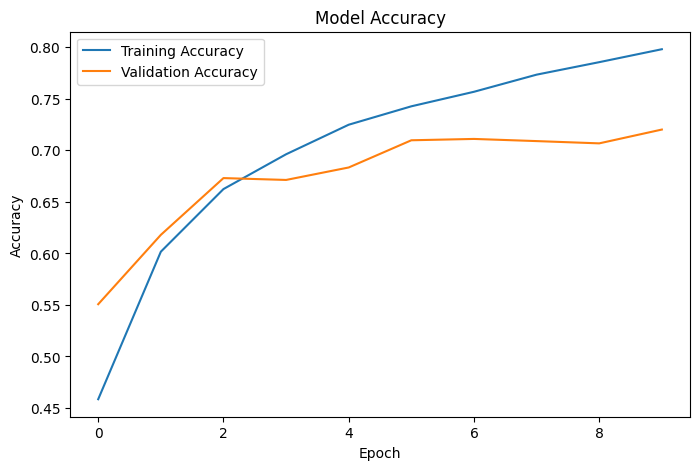

In [10]:
# =========================================================
# STEP 9: PLOT ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

In [11]:
# =========================================================
# STEP 10: MAKE PREDICTIONS
# =========================================================

predictions = model.predict(X_test)

# Predict first image
predicted_label = np.argmax(predictions[0])

print("\nPredicted Class:",
      class_names[predicted_label])

print("Actual Class:",
      class_names[y_test[0][0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step

Predicted Class: cat
Actual Class: cat


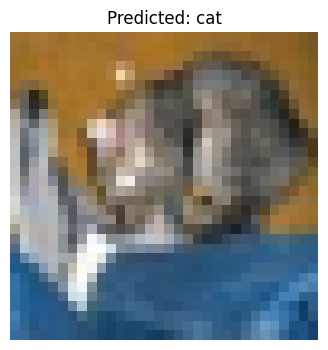

In [12]:
# =========================================================
# STEP 11: DISPLAY TEST IMAGE
# =========================================================

plt.figure(figsize=(4,4))

plt.imshow(X_test[0])

plt.title(
    f"Predicted: {class_names[predicted_label]}"
)

plt.axis('off')

plt.show()


In [13]:
# =========================================================
# STEP 12: SAVE MODEL
# =========================================================

model.save("cnn_image_classification_model.h5")

print("\nModel saved successfully!")


Model saved successfully!
